***Import Required Libraries***

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

***Connect with Drive***

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

***Load Dataset and Handle Missing Values***

In [30]:
missing_tokens = ["?", "unknown", "Unknown", "N/A", "na", "", " "]

df = pd.read_csv(
    "/content/drive/MyDrive/Project_NN/Data/Orig_Data.csv",
    na_values=missing_tokens
)

***Clean Invalid Numerical Values***

In [31]:
df.loc[df["year_build"] <= 0, "year_build"] = np.nan
df.loc[df["sqm"] <= 0, "sqm"] = np.nan
df.loc[df["no_rooms"] <= 0, "no_rooms"] = np.nan


***Drop Irrelevant Columns***

In [32]:
cols_to_drop = [
    'date',
    'house_id',
    '%_change_between_offer_and_purchase',
    'sqm_price',
    'address',
    'zip_code',
    'nom_interest_rate%',
    'dk_ann_infl_rate%',
    'city'
]

df.drop(columns=cols_to_drop, inplace=True)

***Missing Values***

In [33]:
print(df.columns)
print(df.isna().sum())

df = df.dropna()
print(df.isna().sum())

df["purchase_price"].describe()

Index(['quarter', 'house_type', 'sales_type', 'year_build', 'purchase_price',
       'no_rooms', 'sqm', 'area', 'region', 'yield_on_mortgage_credit_bonds%'],
      dtype='object')
quarter                             0
house_type                          0
sales_type                          0
year_build                          0
purchase_price                      0
no_rooms                            0
sqm                                 0
area                                0
region                              0
yield_on_mortgage_credit_bonds%    77
dtype: int64
quarter                            0
house_type                         0
sales_type                         0
year_build                         0
purchase_price                     0
no_rooms                           0
sqm                                0
area                               0
region                             0
yield_on_mortgage_credit_bonds%    0
dtype: int64


,purchase_price
count,9.992300e+04
mean,1.925544e+06
std,1.776786e+06
min,2.502000e+05
25%,8.000000e+05
50%,1.400000e+06
75%,2.450000e+06
max,4.595500e+07


***Convert Price from DKK to USD***

In [34]:
DKK_TO_USD = 0.15

df["price_usd"] = df["purchase_price"] * DKK_TO_USD
df["price_usd_log"] = np.log1p(df["price_usd"])

***Compare between After and before Log***

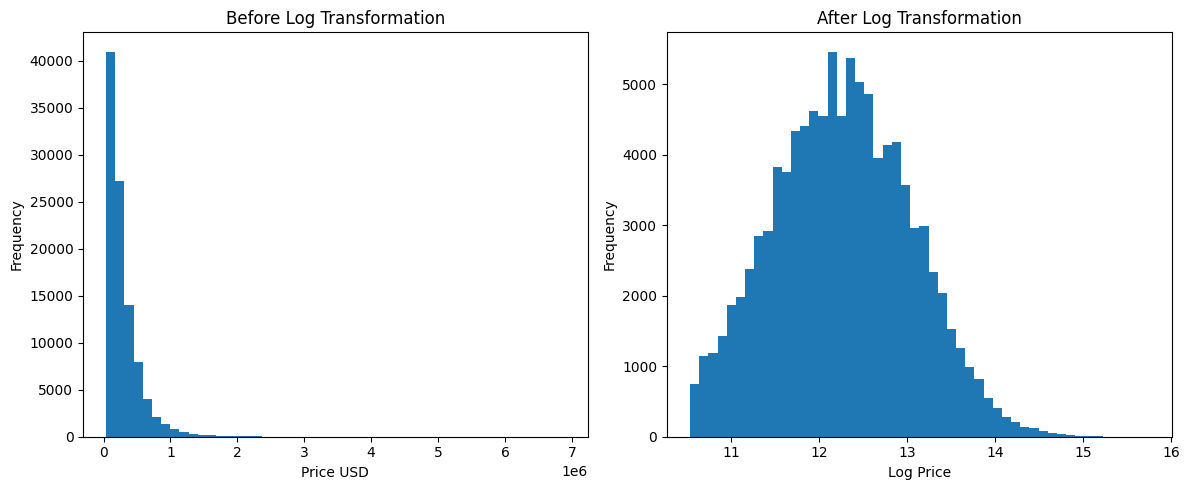

In [35]:
plt.figure(figsize=(12,5))

# Before Log
plt.subplot(1,2,1)
plt.hist(df["price_usd"], bins=50)
plt.title("Before Log Transformation")
plt.xlabel("Price USD")
plt.ylabel("Frequency")

# After Log
plt.subplot(1,2,2)
plt.hist(df["price_usd_log"], bins=50)
plt.title("After Log Transformation")
plt.xlabel("Log Price")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

***Create House Age Feature***

In [36]:
df = df.drop(columns=["purchase_price", "price_usd"])

CURRENT_YEAR = 2025

df["house_age"] = CURRENT_YEAR - df["year_build"]
df["house_age"].describe()

df = df.drop(columns=["year_build"])
df.loc[df["house_age"] == 0, "house_age"] = 1

***Process Quarter Feature***

In [37]:
df["year"] = df["quarter"].str[:4].astype(int)
df["quarter_num"] = df["quarter"].str[-1].astype(int)
df.drop(columns=["quarter"], inplace=True)

***Filter Unrealistic House Ages***

In [ ]:
df = df[df["house_age"] <= 200]
print(df.columns)

***Encode Categorical Variables***

In [39]:
catag_cols = ["house_type", "region", "sales_type", "area"]
df = pd.get_dummies(df, columns=catag_cols, drop_first=True)

***Final Statistical Summary***

In [40]:
print(df[["sqm", "no_rooms", "house_age"]].describe())

                sqm      no_rooms     house_age
count  98661.000000  98661.000000  98661.000000
mean     129.112527      4.371677     67.485562
std       56.620864      1.652317     39.237838
min       26.000000      1.000000      1.000000
25%       89.000000      3.000000     45.000000
50%      123.000000      4.000000     59.000000
75%      160.000000      5.000000     93.000000
max      961.000000     15.000000    200.000000


In [43]:
df.to_csv("/content/drive/MyDrive/Project_NN/Data/Cleaned.csv", index=False)